# OpenCV 传统图像处理实验

该实验以银币（灰度图像，单通道），咖啡（彩色图像，三通道）为对象，实现了多种经典图像处理算法，具体包括：灰度与亮度变换、直方图技术、空间滤波与平滑、边缘检测算子、阈值分割、形态学处理、距离变换与分水岭、轮廓与局部特征、K-means 算法。通过该实验，学习了 OpenCV 的基础用法与各类图像处理算法的相关原理。

注：该实验报告的 Jupyter Notebook 版本以及相关代码可以在 [CV_Task](https://github.com/long753/CV_Task) 上获取，环境配置请参考 README.md 文件。

## 0. 环境导入与图像加载

首先，引入 OpenCV 包，numpy, matpotlib 等必要包；随后，将 coins 保存为灰度图像，coffee 保存为 RGB 图像；最后，利用 matplotlib 将图像呈现出来。具体代码如下：

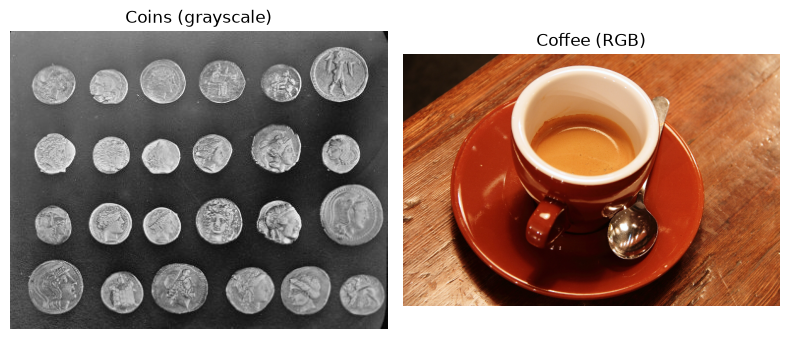

In [9]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# 获取文件路径
image_dir = next((p for p in (Path('images'), Path('../images')) if (p / 'coins_original.png').is_file()), None)
if image_dir is None:
    raise FileNotFoundError('找不到 images/coins_original.png；请从项目根目录或 documents/ 启动 JupyterLab')

# 读取图像
gray = cv2.imread(str(image_dir / 'coins_original.png'), cv2.IMREAD_GRAYSCALE)
coffee_bgr = cv2.imread(str(image_dir / 'coffee_original.png'), cv2.IMREAD_COLOR)
if gray is None or coffee_bgr is None:
    raise FileNotFoundError('示例图片无法读取')
coffee_rgb = cv2.cvtColor(coffee_bgr, cv2.COLOR_BGR2RGB)

# 绘图函数
def show(images, titles, *, figsize=None):
    if len(images) != len(titles):
        raise ValueError('图片与标题数量不同')
    fig, axes = plt.subplots(1, len(images), figsize=figsize or (4 * len(images), 4), squeeze=False)
    for ax, image, title in zip(axes[0], images, titles):
        if image.ndim == 2:
            ax.imshow(image, cmap='gray', vmin=0, vmax=255)
        else:
            ax.imshow(image)
        ax.set_title(title)
        ax.axis('off')
    fig.tight_layout()
    plt.show()

# 绘制图像
show([gray, coffee_rgb], ['Coins (grayscale)', 'Coffee (RGB)'])

## 1. 灰度与亮度变换

灰度图像的 RGB 分量的数值相同，因而灰度图像的像素有256个分级。相较于彩色图像而言，灰度图像的计算速度更快，但也舍弃了部分信息。常见的图像灰度化算法如 rgb2gray 的公式为：
$$ 
I(x,y)=0.3*I_R(x,y)+0.59*I_G(x,y)+0.11*I_B(x,y) 
$$ 
该公式的系数来自于人眼对r、g、b三色的敏感程度。在 OpenCV 中，常常使用 `convertScaleAbs` 函数来实现图像的灰度与亮度变化，公式为：
$$
g=\mathrm{clip}(\alpha f+\beta,0,255)
$$ 
其中，$\alpha$ 控制对比度，$\beta$ 控制亮度。

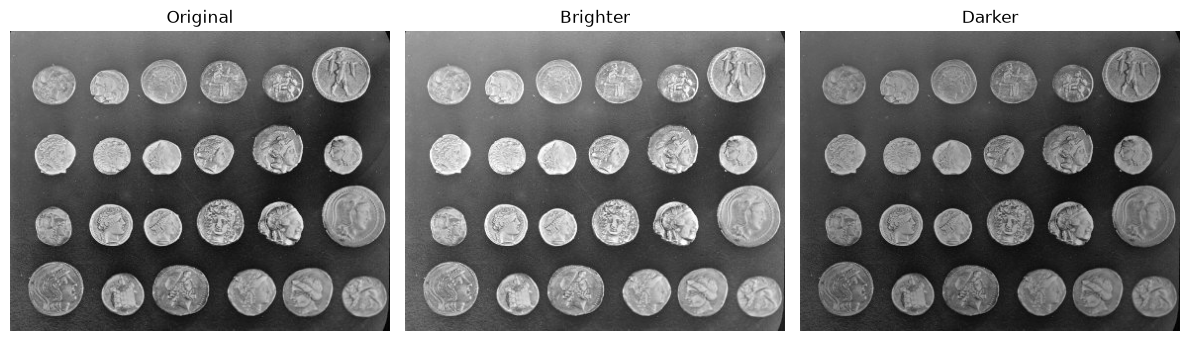

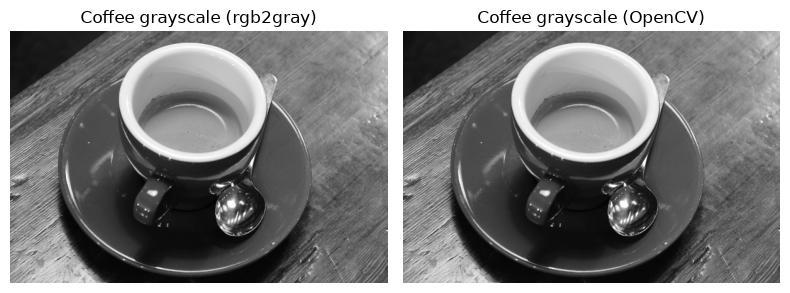

In [10]:
# 自定义 rgb2gray 函数，使用加权平均法将 RGB 图像转换为灰度图像
def rgb2gray(rgb):
    return np.dot(rgb[..., :3], [0.299, 0.587, 0.114]).astype(np.uint8)

# 彩色图像转换为灰度图像的两种方法
coffee_gray_rgb2gray = rgb2gray(coffee_rgb)
coffee_gray = cv2.cvtColor(coffee_bgr, cv2.COLOR_BGR2GRAY)

# 调节灰度图的亮度与对比度
brighter = cv2.convertScaleAbs(gray, alpha=1.00, beta=25)
darker = cv2.convertScaleAbs(gray, alpha=0.80, beta=0)

# 绘图
show([gray, brighter, darker], ['Original', 'Brighter', 'Darker'])
show([coffee_gray_rgb2gray, coffee_gray], ['Coffee grayscale (rgb2gray)', 'Coffee grayscale (OpenCV)'])

## 2. 直方图技术

图像直方图描述了一张图片的像素值分布的情况，对于彩色图片而言，则需要计算每个通道的图像直方图。

直方图均衡化(Histogram Equalization, HE)，是指通过非线性灰度映射，让原本集中在较窄的灰度值尽可能分散到更宽的范围，进而增强图像的对比度。在 OpenCV 中，通常使用函数 `equalizeHist` 来实现。

自适应直方图均衡化(Contrast Limited Adaptive Histogram Equalization, CLAHE)在 HE 的基础上提出了两个改进：一是将图像划分为多个小区域，然后对各个小区域分别计算直方图，随后使用平滑插值过度。二是通过引入控制裁剪阈值（clipLimit），限制对比度过度增强。在 OpenCV 中，通常使用函数 `createCLAHE` 来实现。

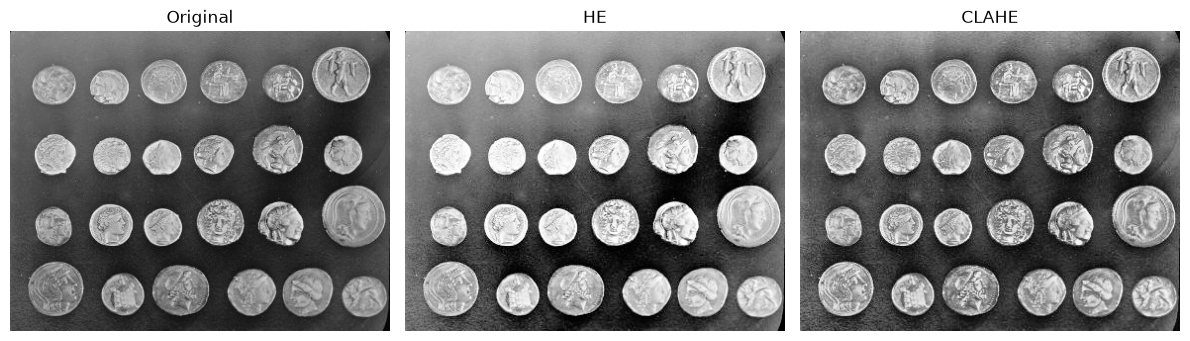

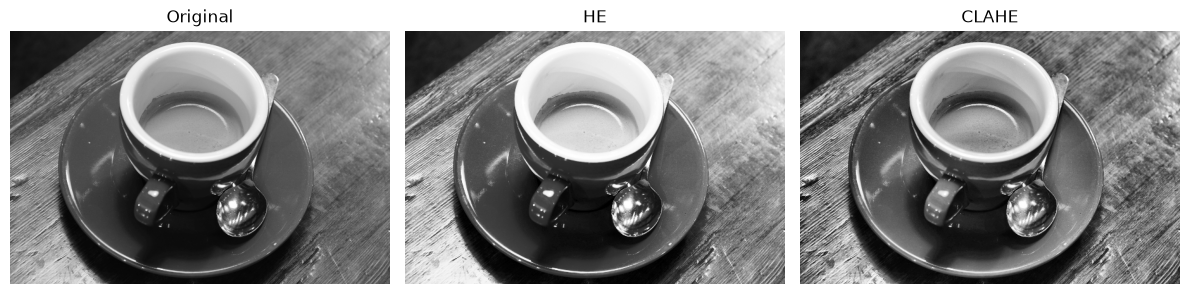

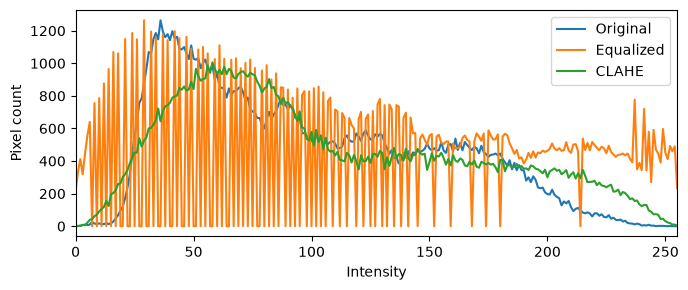

In [11]:
# 硬币图像的直方图均衡化
equalized = cv2.equalizeHist(gray)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(gray)

# 咖啡的直方图均衡化
coffee_equalized = cv2.equalizeHist(coffee_gray)
coffee_clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(coffee_gray)

# 绘图
show([gray, equalized, clahe], ['Original', 'HE', 'CLAHE'])
show([coffee_gray, coffee_equalized, coffee_clahe], ['Original', 'HE', 'CLAHE'])

# 统计硬币直方图
fig, ax = plt.subplots(figsize=(7, 3))
for image, label in ((gray, 'Original'), (equalized, 'Equalized'), (clahe, 'CLAHE')):
    hist = cv2.calcHist([image], [0], None, [256], [0, 256])
    ax.plot(np.arange(256), hist.ravel(), label=label)
ax.set(xlabel='Intensity', ylabel='Pixel count', xlim=(0, 255))
ax.legend()
fig.tight_layout()
plt.show()

## 3. 空间滤波与平滑

空间滤波利用一个像素及其领域内其他像素的信息，重新计算该像素的值，主要用于去除噪声、平滑图像、增强边缘及提取局部特征。

高斯滤波(Gaussian Blur, GB)的核心思想是：对领域像素进行加权平均，距离中心越近，权重越大；距离越远，权重越小。在 OpenCV 中通常使用 `GaussianBlur` 函数来实现。权重的具体计算公式如下：
$$
G(x,y)=\frac1{2\pi\sigma^2}\exp\left(-\frac{x^2+y^2}{2\sigma^2}\right)
$$

中值滤波(Median Blur, MB)与 GB 不同，他不计算加权平均值，而是直接选择领域像素的中位数。在 OpenCV 中通常使用 `medianBlur` 函数来实现。

双边滤波(Bilateral Filter, BF)则同时考虑像素之间的空间距离与像素值差异，二者共同决定滤波权重。在 OpenCV 中通常使用 `bilateralFilter` 函数来实现。具体的计算计算公式如下：
$$
w(p,q)={e^{-\frac{\|p-q\|^2}{2\sigma_s^2}}}\cdot{e^{-\frac{(I_p-I_q)^2}{2\sigma_r^2}}}
$$

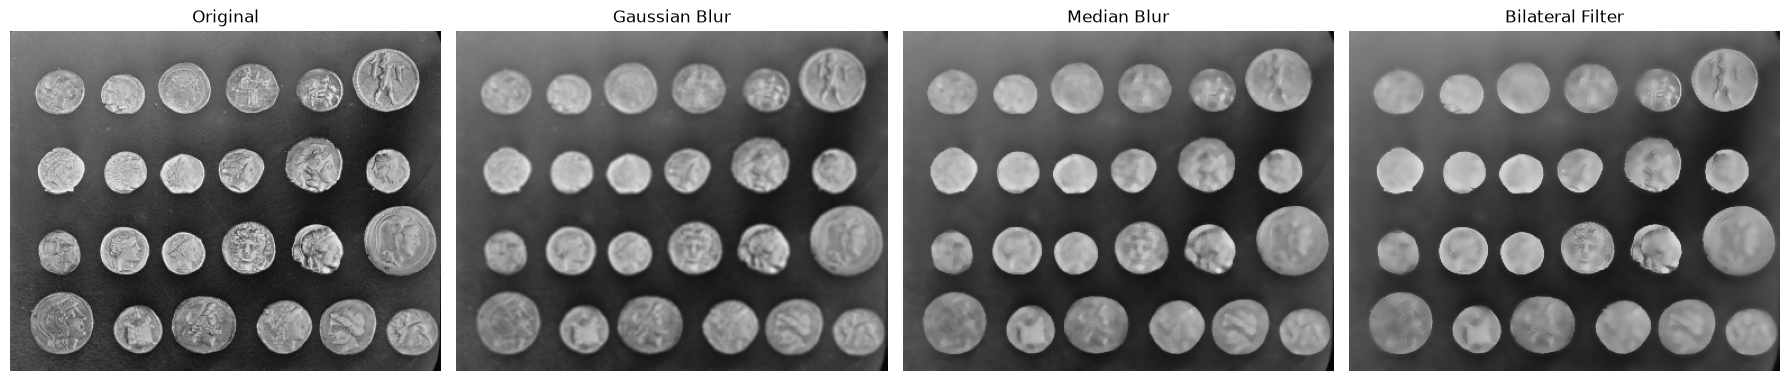

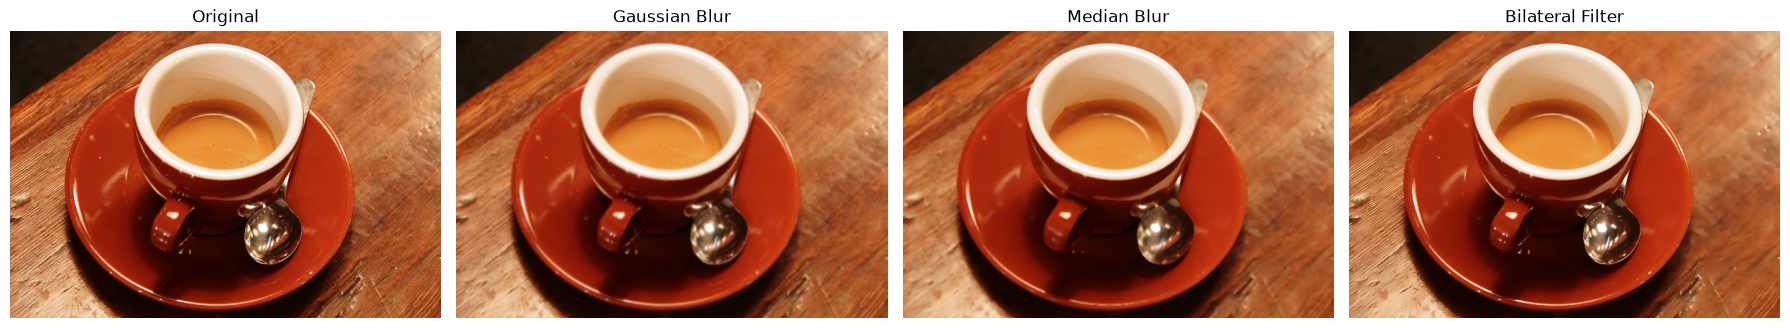

In [12]:
# 灰度图像（硬币）的单通道滤波
coin_gaussian = cv2.GaussianBlur(gray, (5, 5), 0)
coin_median = cv2.medianBlur(gray, 5)
coin_bilateral = cv2.bilateralFilter(gray, 9, 50, 50)

# 彩色图像（咖啡）的单通道滤波
coffee_gaussian = cv2.GaussianBlur(coffee_rgb, (5, 5), 0)
coffee_median = cv2.medianBlur(coffee_rgb, 5)
coffee_bilateral = cv2.bilateralFilter(coffee_rgb, 9, 50, 50)

# 绘图
show([gray, coin_gaussian, coin_median, coin_bilateral],
     ['Original', 'Gaussian Blur', 'Median Blur', 'Bilateral Filter'], figsize=(18, 4))
show([coffee_rgb, coffee_gaussian, coffee_median, coffee_bilateral],
     ['Original', 'Gaussian Blur', 'Median Blur', 'Bilateral Filter'], figsize=(18, 4))

## 4. 边缘检测算子

边缘检测主要用于识别图像中灰度或颜色发生显著变化的位置，从而提取物体轮廓、边界和结构信息。

Sobel 是基于一阶导数的边缘检测算子，通过分别计算图像在水平和垂直方向的灰度梯度，再结合两个方向的梯度得到的边缘强度。该算法的特点为：边缘梯度强度明显，但边缘可能较粗。

Laplacian 是基于二阶导数的边缘检测算子，通过计算图像在水平和垂直方向的灰度二阶导数之和来得到边缘强度。该算法的特点为：可以突出快速灰度变化，但可能产生双边缘。

Canny 则相对复杂，主要包含高斯滤波、梯度计算、非极大值抑制、双阈值分类、滞后阈值链接五个关键步骤。该算法的特点为：边缘较细，但部分边缘细节容易缺漏。

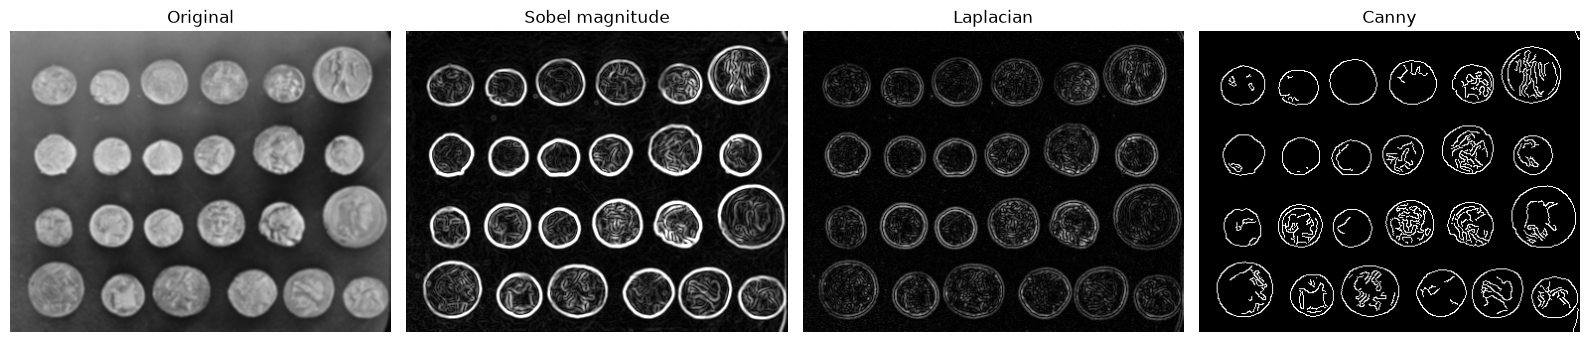

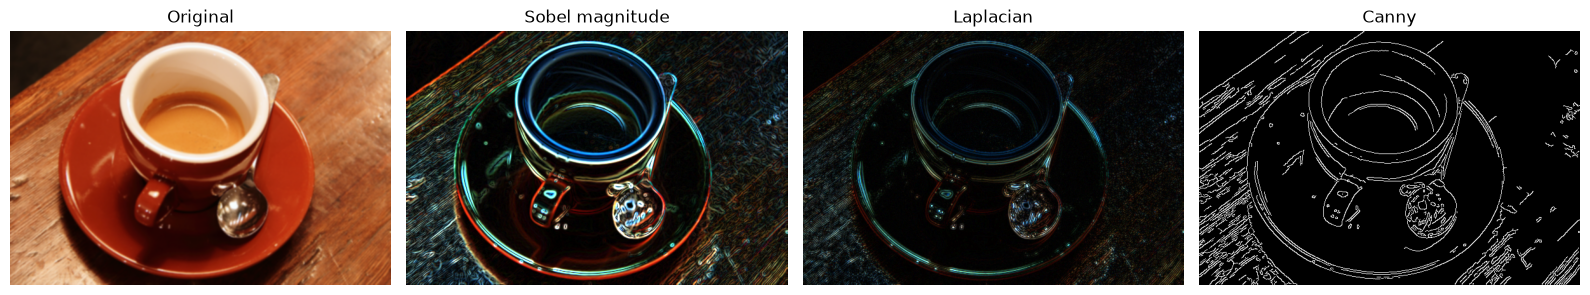

In [13]:
# 银币的边缘检测
coin_gx = cv2.Sobel(coin_gaussian, cv2.CV_64F, 1, 0, ksize=3)
coin_gy = cv2.Sobel(coin_gaussian, cv2.CV_64F, 0, 1, ksize=3)
coin_sobel = cv2.convertScaleAbs(cv2.magnitude(coin_gx, coin_gy))
coin_laplacian = cv2.convertScaleAbs(cv2.Laplacian(coin_gaussian, cv2.CV_64F, ksize=3))
coin_canny = cv2.Canny(coin_gaussian, 60, 150)

# 咖啡的边缘检测
coffee_gx = cv2.Sobel(coffee_gaussian, cv2.CV_64F, 1, 0, ksize=3)
coffee_gy = cv2.Sobel(coffee_gaussian, cv2.CV_64F, 0, 1, ksize=3)
coffee_sobel = cv2.convertScaleAbs(cv2.magnitude(coffee_gx, coffee_gy))
coffee_laplacian = cv2.convertScaleAbs(cv2.Laplacian(coffee_gaussian, cv2.CV_64F, ksize=3))
coffee_canny = cv2.Canny(coffee_gaussian, 60, 150)

# 绘图
show([coin_gaussian, coin_sobel, coin_laplacian, coin_canny],
     ['Original', 'Sobel magnitude', 'Laplacian', 'Canny'])
show([coffee_gaussian, coffee_sobel, coffee_laplacian, coffee_canny],
     ['Original', 'Sobel magnitude', 'Laplacian', 'Canny'])

## 5. 阈值分割

阈值分割是一种根据像素的灰度值，将图像划分为前景和背景两个区域的算法，我们通常也称阈值分割为二值化算法。

固定阈值顾名思义是人为指定一个固定阈值，整张图像中的所有像素都使用这个阈值进行分割，OpenCV 中通常使用 `threshold` 函数来实现。

Otsu 无需认为指定阈值，而是根据整张图像的灰度直方图，自动计算一个最合适的全局阈值，OpenCV 中通常使用 `threshold` 函数来实现。

自适应阈值则不让整张图像使用统一的阈值，而是根据每个像素周围的局部领域，动态计算该位置的阈值。通常分为局部均值阈值与局部高斯阈值两种算法，OpenCV 中通常使用 `adaptiveThreshold` 函数来实现。

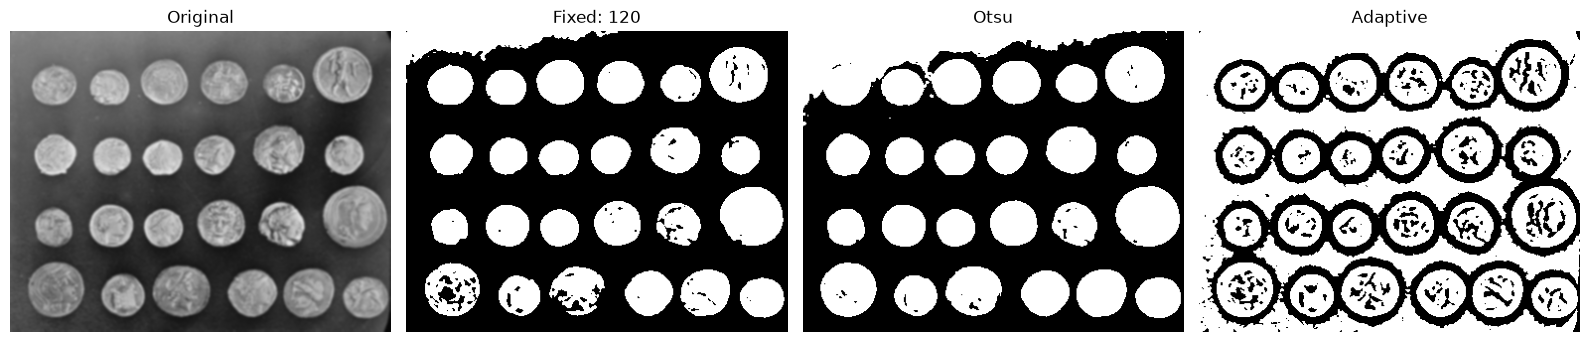

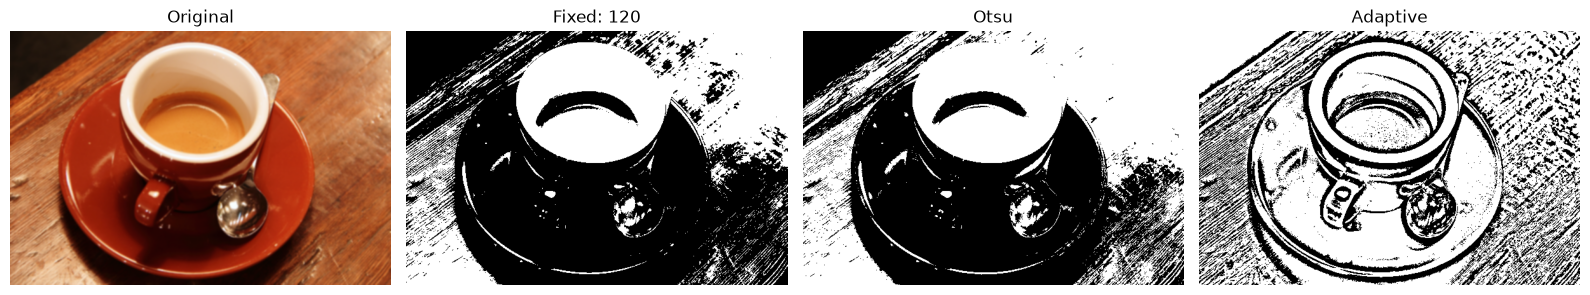

In [14]:
# 银币的阈值分割
_, coin_fixed_mask = cv2.threshold(coin_gaussian, 120, 255, cv2.THRESH_BINARY)
coin_otsu_level, coin_otsu_mask = cv2.threshold(coin_gaussian, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
coin_adaptive_mask = cv2.adaptiveThreshold(coin_gaussian, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 31, 5)

# 咖啡的阈值分割
_, coffee_fixed_mask = cv2.threshold(coffee_gray, 120, 255, cv2.THRESH_BINARY)
coffee_otsu_level, coffee_otsu_mask = cv2.threshold(coffee_gray, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
coffee_adaptive_mask = cv2.adaptiveThreshold(coffee_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 31, 5)

# 绘图
show([coin_gaussian, coin_fixed_mask, coin_otsu_mask, coin_adaptive_mask],
     ['Original', 'Fixed: 120', 'Otsu', 'Adaptive'])
show([coffee_gaussian, coffee_fixed_mask, coffee_otsu_mask, coffee_adaptive_mask],
     ['Original', 'Fixed: 120', 'Otsu', 'Adaptive'])

## 6. 形态学处理

图像形态学处理是一类基于图像形状和结构的处理方法，主要用于消除噪声、填补孔洞、连接断裂区域以及提取目标轮廓。此外，形态学处理一边用于二值图像。

腐蚀(Erosion)会缩小白色区域，主要用于去除小型白色噪声。具体原理为：只有当覆盖区域内所有像素都是白色时，中心位置才保留为白色。OpenCV 中主要使用 `erode` 函数来实现。

膨胀(Dilation)会扩大白色区域，主要用于填补小间隙。具体原理为：对于全1结构元素，只要覆盖区域内存在白色像素，中心位置就变为白色。OpenCV 中主要使用 `dilate` 函数来实现。

开运算（先腐蚀后膨胀）用于去除较小的白色噪声。OpenCV 中主要使用 `morphologyEx` 函数来实现。

闭运算（先膨胀后腐蚀）用于填补较小的黑色孔洞。OpenCV 中主要使用 `morphologyEx` 函数来实现。

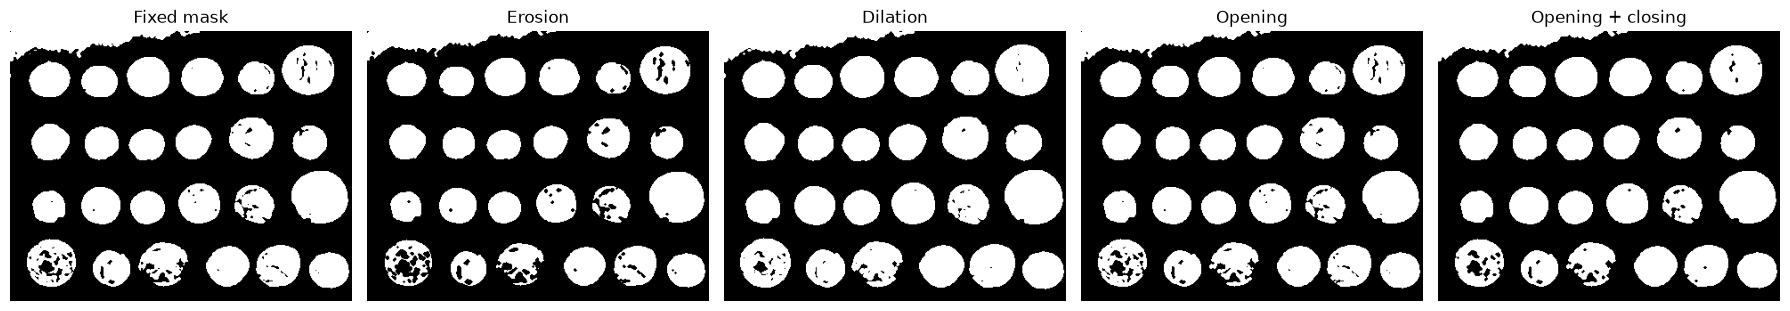

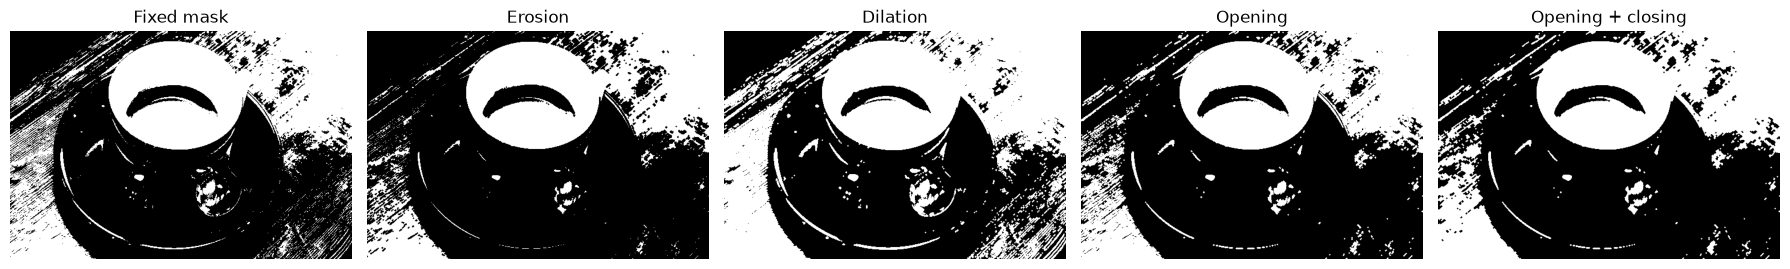

In [15]:
# 硬币的形态学处理
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
coin_eroded = cv2.erode(coin_fixed_mask, kernel, iterations=1)
coin_dilated = cv2.dilate(coin_fixed_mask, kernel, iterations=1)
coin_opened = cv2.morphologyEx(coin_fixed_mask, cv2.MORPH_OPEN, kernel)
clean_mask = cv2.morphologyEx(coin_opened, cv2.MORPH_CLOSE, kernel)

# 咖啡的形态学处理
coffee_eroded = cv2.erode(coffee_fixed_mask, kernel, iterations=1)
coffee_dilated = cv2.dilate(coffee_fixed_mask, kernel, iterations=1)
coffee_opened = cv2.morphologyEx(coffee_fixed_mask, cv2.MORPH_OPEN, kernel)
coffee_clean_mask = cv2.morphologyEx(coffee_opened, cv2.MORPH_CLOSE, kernel)

# 绘图
show([coin_fixed_mask, coin_eroded, coin_dilated, coin_opened, clean_mask],
     ['Fixed mask', 'Erosion', 'Dilation', 'Opening', 'Opening + closing'], figsize=(18, 4))
show([coffee_fixed_mask, coffee_eroded, coffee_dilated, coffee_opened, coffee_clean_mask],
     ['Fixed mask', 'Erosion', 'Dilation', 'Opening', 'Opening + closing'], figsize=(18, 4))

## 7. 距离变换与分水岭

距离变换(Distance Transform)将二值图中每个白色像素的值替换为它到最近黑色像素的距离。目标内部的高值区域可作为“确定前景”种子，OpenCV 使用 `distanceTransform` 实现。先对二值掩膜开闭运算，再膨胀前景以划出待判定的边缘带；膨胀区域之外是确定背景。

分水岭(Watershed)把图像看作地形：从已标记的种子区域出发，依据图像梯度扩展标签，相邻区域相遇处形成边界。用 `connectedComponents` 给前景种子编号，背景设为 1，未知区域设为 0；`watershed` 返回的边界标签为 -1。本节分别处理硬币灰度图和咖啡彩色图，分水岭输入须为三通道 BGR 图像。

结果取决于第六章的二值掩膜和种子阈值；咖啡图中亮区域不一定是杯子。反光、阴影或相连的物体可能造成过分割、欠分割，**分割区域数不能当作真实目标数**。

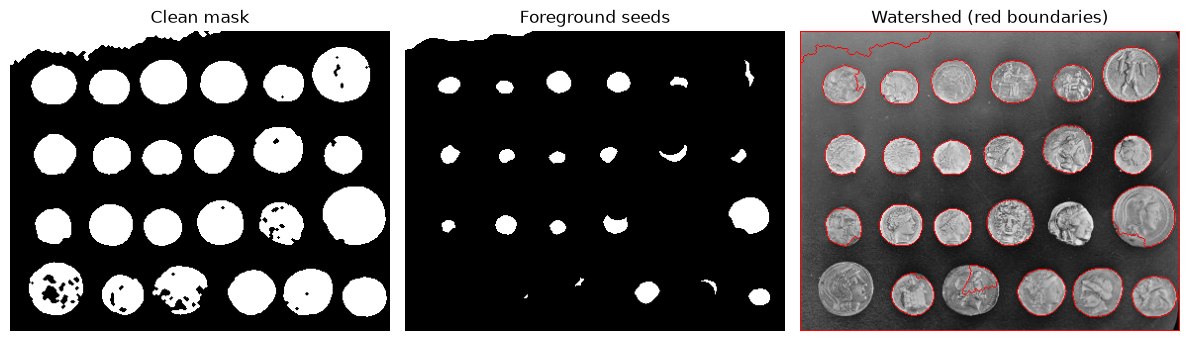

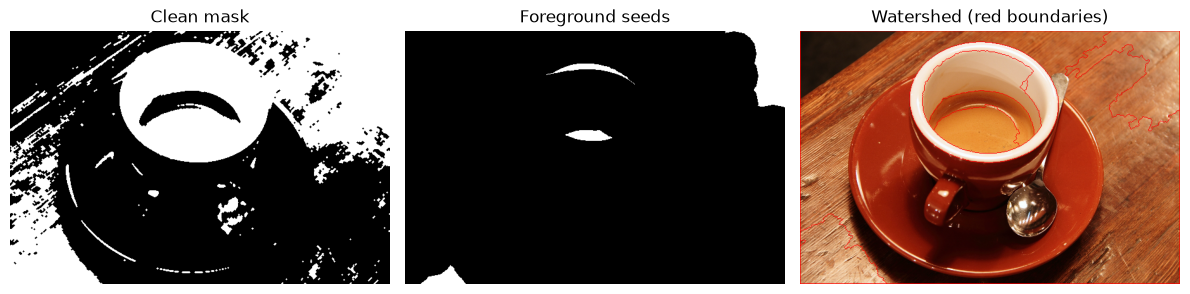

硬币前景区域数：23；咖啡前景区域数：6


In [16]:
# 硬币：距离变换、前景/背景种子和分水岭
coin_distance = cv2.distanceTransform(clean_mask, cv2.DIST_L2, 5)
_, coin_sure_fg = cv2.threshold(coin_distance, 0.4 * coin_distance.max(), 255, cv2.THRESH_BINARY)
coin_sure_fg = coin_sure_fg.astype(np.uint8)
coin_sure_bg = cv2.dilate(clean_mask, kernel, iterations=3)
coin_unknown = cv2.subtract(coin_sure_bg, coin_sure_fg)
_, coin_markers = cv2.connectedComponents(coin_sure_fg)
coin_markers += 1  # 背景为 1，未知区域为 0
coin_markers[coin_unknown == 255] = 0
coin_markers = cv2.watershed(cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR), coin_markers)
coin_segmented = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)
coin_segmented[coin_markers == -1] = (255, 0, 0)

# 咖啡：沿用第六章的二值掩膜，用原彩色图像计算分水岭边界
coffee_distance = cv2.distanceTransform(coffee_clean_mask, cv2.DIST_L2, 5)
_, coffee_sure_fg = cv2.threshold(coffee_distance, 0.4 * coffee_distance.max(), 255, cv2.THRESH_BINARY)
coffee_sure_fg = coffee_sure_fg.astype(np.uint8)
coffee_sure_bg = cv2.dilate(coffee_clean_mask, kernel, iterations=3)
coffee_unknown = cv2.subtract(coffee_sure_bg, coffee_sure_fg)
_, coffee_markers = cv2.connectedComponents(coffee_sure_fg)
coffee_markers += 1
coffee_markers[coffee_unknown == 255] = 0
coffee_markers = cv2.watershed(coffee_bgr.copy(), coffee_markers)
coffee_segmented = coffee_rgb.copy()
coffee_segmented[coffee_markers == -1] = (255, 0, 0)

# 绘图：红色为分水岭边界
show([clean_mask, coin_sure_fg, coin_segmented],
     ['Clean mask', 'Foreground seeds', 'Watershed (red boundaries)'])
show([coffee_clean_mask, coffee_sure_fg, coffee_segmented],
     ['Clean mask', 'Foreground seeds', 'Watershed (red boundaries)'])
print(f'硬币前景区域数：{np.count_nonzero(np.unique(coin_markers) > 1)}；'
      f'咖啡前景区域数：{np.count_nonzero(np.unique(coffee_markers) > 1)}')

## 8. 轮廓与局部特征

轮廓(Contour)是在二值掩膜中由相邻前景像素围成的边界。`findContours` 提取轮廓后，可以通过 `contourArea` 和 `arcLength` 计算面积 $A$ 与周长 $P$，再用圆形度 $C=4\pi A/P^2$ 描述形状；理想圆形的 $C$ 为 1。此处使用 `RETR_EXTERNAL` 仅提取最外层轮廓，并过滤面积小于 80 像素平方的噪声。咖啡图的轮廓是亮度阈值轮廓，不等于杯子的完整外形。

ORB(Oriented FAST and Rotated BRIEF)先在灰度图上检测局部关键点，再为关键点生成二进制描述子，可用于图像匹配。`detectAndCompute` 的输入是原始灰度图，而不是轮廓二值图；与轮廓的面积、周长等整体形状特征不同，ORB 反映局部纹理。以下分别对硬币与咖啡图像提取轮廓和关键点。

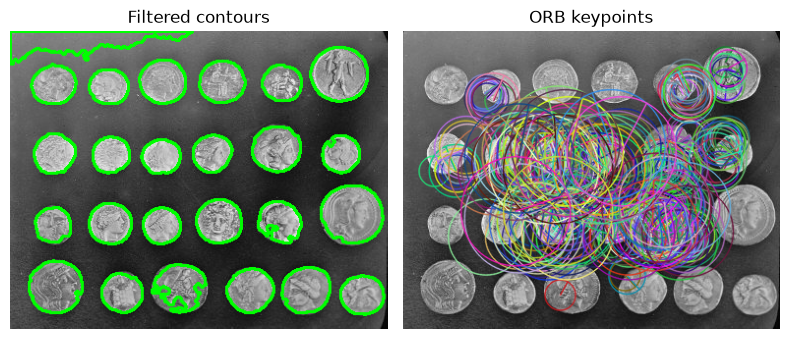

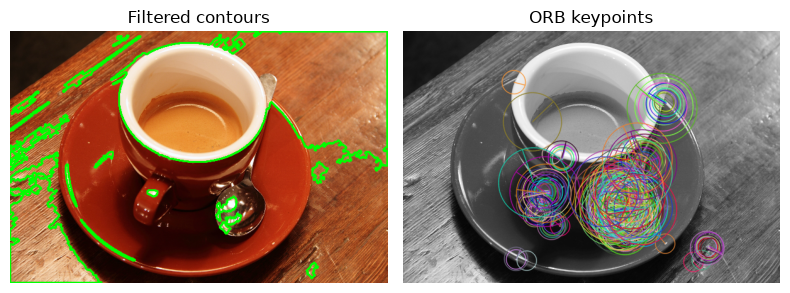

In [20]:
# 硬币：轮廓形状与 ORB 局部特征
coin_contours, _ = cv2.findContours(clean_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
coin_contours = [c for c in coin_contours if cv2.contourArea(c) >= 80]
coin_outlined = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)
cv2.drawContours(coin_outlined, coin_contours, -1, (0, 255, 0), 2)
orb = cv2.ORB_create(nfeatures=300)
coin_keypoints, coin_descriptors = orb.detectAndCompute(gray, None)
coin_features = cv2.drawKeypoints(gray, coin_keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

# 咖啡：相同的计算步骤，轮廓基于亮度阈值掩膜
coffee_contours, _ = cv2.findContours(coffee_clean_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
coffee_contours = [c for c in coffee_contours if cv2.contourArea(c) >= 80]
coffee_outlined = coffee_rgb.copy()
cv2.drawContours(coffee_outlined, coffee_contours, -1, (0, 255, 0), 2)
coffee_keypoints, coffee_descriptors = orb.detectAndCompute(coffee_gray, None)
coffee_features = cv2.drawKeypoints(coffee_gray, coffee_keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

# 绘图
show([coin_outlined, cv2.cvtColor(coin_features, cv2.COLOR_BGR2RGB)],
     ['Filtered contours', 'ORB keypoints'])
show([coffee_outlined, cv2.cvtColor(coffee_features, cv2.COLOR_BGR2RGB)],
     ['Filtered contours', 'ORB keypoints'])

## 9. K-means 聚类分割

K-means 是无监督聚类方法：指定类别数 $K$ 后，把每个像素分配给距离最近的聚类中心，并不断更新中心以减少类内平方误差。在 OpenCV 中用 `kmeans` 实现。输入灰度硬币图时，每个像素是一个灰度值；输入彩色咖啡图时，每个像素是 RGB 三维向量。

下面将两张图各自聚成 4 类，展示原图、用聚类中心替代原像素的量化图，以及类别编号图。聚类编号只是任意标签，颜色相近的杯子、碟子和桌面可能归到同一类，**聚类标签不代表物体语义**。修改类别数 `K` 可比较细节保留与区域破碎之间的取舍。

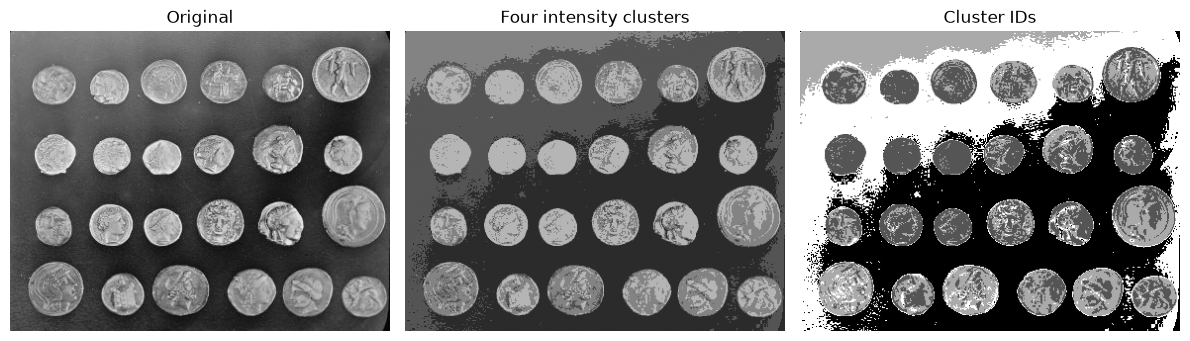

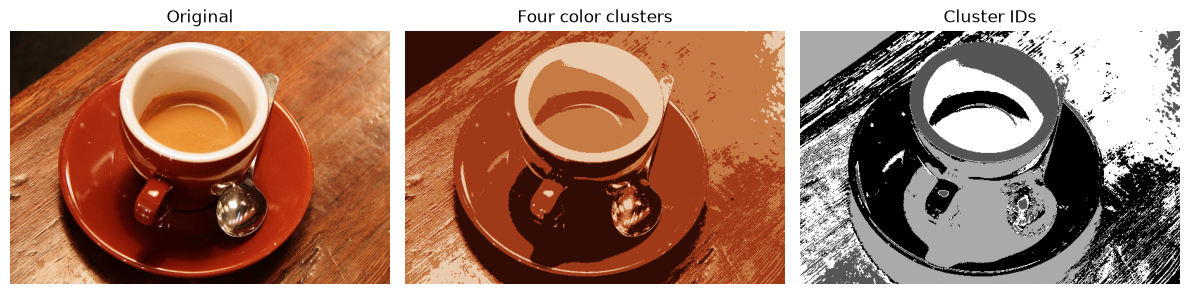

In [19]:
# 硬币：用一维灰度值聚类
coin_pixels = gray.reshape(-1, 1).astype(np.float32)
criteria = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_MAX_ITER, 20, 0.2)
cv2.setRNGSeed(42)
_, coin_labels, coin_centers = cv2.kmeans(coin_pixels, 4, None, criteria, 3, cv2.KMEANS_PP_CENTERS)
coin_quantized = coin_centers[coin_labels.ravel()].reshape(gray.shape).astype(np.uint8)
coin_label_image = coin_labels.reshape(gray.shape).astype(np.uint8) * 85

# 咖啡：用三维 RGB 颜色聚类，同样固定随机种子便于比较
coffee_pixels = coffee_rgb.reshape(-1, 3).astype(np.float32)
cv2.setRNGSeed(42)
_, coffee_labels, coffee_centers = cv2.kmeans(coffee_pixels, 4, None, criteria, 3, cv2.KMEANS_PP_CENTERS)
coffee_quantized = coffee_centers[coffee_labels.ravel()].reshape(coffee_rgb.shape).astype(np.uint8)
coffee_label_image = coffee_labels.reshape(coffee_rgb.shape[:2]).astype(np.uint8) * 85

# 绘图；编号图中的灰度值 0、85、170、255 分别对应四个聚类编号
show([gray, coin_quantized, coin_label_image],
     ['Original', 'Four intensity clusters', 'Cluster IDs'])
show([coffee_rgb, coffee_quantized, coffee_label_image],
     ['Original', 'Four color clusters', 'Cluster IDs'])